### Introducción a los modelos de clasificación de Machine Learning
En el aprendizaje automático (Machine Learning), la clasificación se refiere al proceso de asignar una etiqueta a un objeto. Por ejemplo, si estamos tratando de identificar si una imagen es un perro o un gato, la clasificación implicaría etiquetar la imagen como "perro" o "gato". Existen muchos modelos de clasificación diferentes que se utilizan en Machine Learning, y cada uno de ellos tiene sus propias fortalezas y debilidades. En esta clase de Jupyter Notebook, exploraremos algunos de los modelos más comunes de clasificación de Machine Learning, y veremos cómo se comparan entre sí en términos de rendimiento.

In [2]:
import os
import numpy as np 
import pandas as pd 
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
warnings.filterwarnings("ignore")
pd.set_option("display.max_rows",None)
from sklearn import preprocessing
import matplotlib 
matplotlib.style.use('ggplot')
from sklearn.preprocessing import LabelEncoder

In [3]:
df=pd.read_csv("datos_procesos.csv", sep='|')
df.head()

,ID_Proceso,Uso_CPU,Uso_Memoria,Numero_Hilos,Tiempo_Ejecucion,Numero_Errores,Tipo_Proceso,Estado
0,1,37.454012,59.515562,16,8.184879,3,Aplicación,0
1,2,95.071431,36.471714,18,76.195256,8,Aplicación,0
2,3,73.199394,0.537562,21,46.991138,3,Aplicación,0
3,4,59.865848,56.108773,28,87.884325,4,Aplicación,0
4,5,15.601864,89.657041,39,4.622599,1,Sistema,0


In [4]:
df.dtypes

ID_Proceso            int64
Uso_CPU             float64
Uso_Memoria         float64
Numero_Hilos          int64
Tiempo_Ejecucion    float64
Numero_Errores        int64
Tipo_Proceso         object
Estado                int64
dtype: object

In [6]:
string_col = df.select_dtypes(include="object").columns
df[string_col]=df[string_col].astype("string")

In [5]:
df.dtypes

ID_Proceso                   int64
Uso_CPU                    float64
Uso_Memoria                float64
Numero_Hilos                 int64
Tiempo_Ejecucion           float64
Numero_Errores               int64
Tipo_Proceso        string[python]
Estado                       int64
dtype: object

In [10]:
string_col=df.select_dtypes("string").columns.to_list()
string_col

['Tipo_Proceso']

In [12]:
num_col=df.columns.to_list()
#print(num_col)
for col in string_col:
    num_col.remove(col)
num_col.remove("Estado")
num_col

['ID_Proceso',
 'Uso_CPU',
 'Uso_Memoria',
 'Numero_Hilos',
 'Tiempo_Ejecucion',
 'Numero_Errores']

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID_Proceso,1000000.0,500000.500000,288675.278932,1.000000,250000.750000,500000.500000,750000.250000,1000000.000000
Uso_CPU,1000000.0,50.033449,28.859113,0.000052,25.034021,50.055597,75.009673,99.999831
Uso_Memoria,1000000.0,49.947866,28.851514,0.000038,24.999623,49.895350,74.924148,99.999938
Numero_Hilos,1000000.0,25.030640,14.150159,1.000000,13.000000,25.000000,37.000000,49.000000
Tiempo_Ejecucion,1000000.0,50.043250,28.829111,0.100083,25.074789,50.040186,75.030119,99.999992
Numero_Errores,1000000.0,5.003483,2.237005,0.000000,3.000000,5.000000,6.000000,19.000000
Estado,1000000.0,0.064631,0.245874,0.000000,0.000000,0.000000,0.000000,1.000000


### Matriz de correlación
Es necesario eliminar las variables correlacionadas para mejorar el modelo. Uno puede encontrar correlaciones usando la función pandas ".corr()" y puede visualizar la matriz de correlación usando plotly express.
Los tonos más claros representan una correlación positiva
Los tonos más oscuros representan una correlación negativa

### OUTLIER
Un diagrama de caja (o diagrama de caja y bigotes) muestra la distribución de datos cuantitativos de una manera que facilita las comparaciones entre variables. El cuadro muestra los cuartiles del conjunto de datos, mientras que los bigotes se extienden para mostrar el resto de la distribución. El diagrama de caja (también conocido como diagrama de caja y bigotes) es una forma estandarizada de mostrar la distribución de datos basada en el resumen de cinco números:

* Mínimo
* Primer cuartil
* Mediana
* Tercer cuartil
* Máximo.
En el diagrama de caja más simple, el rectángulo central abarca desde el primer cuartil hasta el tercer cuartil (el rango intercuartil o IQR). Un segmento dentro del rectángulo muestra la mediana y los "bigotes" por encima y por debajo del cuadro muestran las ubicaciones del mínimo y máximo.
​

In [14]:
df.columns

Index(['ID_Proceso', 'Uso_CPU', 'Uso_Memoria', 'Numero_Hilos',
       'Tiempo_Ejecucion', 'Numero_Errores', 'Tipo_Proceso', 'Estado'],
      dtype='object')

In [15]:
df.shape

(1000000, 8)

### Data Preprocessing

El preprocesamiento de datos es un paso integral en el aprendizaje automático, ya que la calidad de los datos y la información útil que se puede derivar de ellos afecta directamente la capacidad de aprendizaje de nuestro modelo; Por lo tanto, es extremadamente importante que preprocesemos nuestros datos antes de introducirlos en nuestro modelo.

Los conceptos que cubriré en este artículo son

1. Control de valores nulos
2. Escalado de características
3. Manejo de variables categóricas

###  Manejo de valores nulos:
En cualquier conjunto de datos del mundo real, siempre hay pocos valores nulos. Realmente no importa si se trata de una regresión, clasificación o cualquier otro tipo de problema, ningún modelo puede manejar estos valores NULL o NaN por sí solo, por lo que debemos intervenir.

> En python NULL se representa con NaN. Así que no se confunda entre estos dos, se pueden usar intercambiablemente.

In [16]:
# Checking for NULLs in the data
df.isnull().sum()

ID_Proceso          0
Uso_CPU             0
Uso_Memoria         0
Numero_Hilos        0
Tiempo_Ejecucion    0
Numero_Errores      0
Tipo_Proceso        0
Estado              0
dtype: int64

### 2. Escalado de características
¿Por qué deberíamos usar la escala de características?
La primera pregunta que debemos abordar: ¿por qué necesitamos escalar las variables en nuestro conjunto de datos? Algunos algoritmos de aprendizaje automático son sensibles al escalado de características, mientras que otros son prácticamente invariantes a él. Permítanme explicarlo con más detalle.

#### 1. Algoritmos basados en la distancia:
Los algoritmos de distancia como "KNN", "K-means" y "SVM" son los más afectados por la gama de características. Esto se debe a que detrás de escena están utilizando distancias entre puntos de datos para determinar su similitud. Si dos características tienen escalas diferentes, existe la posibilidad de que se otorgue un mayor peso a las características con mayor magnitud. Esto afectará el rendimiento del algoritmo de aprendizaje automático y, obviamente, no queremos que nuestro algoritmo esté sesgado hacia una característica.

Por lo tanto, escalamos nuestros datos antes de emplear un algoritmo basado en la distancia para que todas las características contribuyan por igual al resultado.

<img src="https://miro.medium.com/max/1000/0*MZKG8sTIdSNv6TXB" width=50%>

#### 2. Algoritmos basados en árbol:
Los algoritmos basados en árboles, por otro lado, son bastante insensibles a la escala de las características. Piénselo, un árbol de decisión solo divide un nodo en función de una sola característica. El árbol de decisión divide un nodo en una característica que aumenta la homogeneidad del nodo. Esta división en una característica no está influenciada por otras características.

Por lo tanto, prácticamente no hay efecto de las características restantes en la división. ¡Esto es lo que los hace invariantes a la escala de las características!
<img src="https://miro.medium.com/max/925/0*U0rcW7XrdHpvI0hU.jpeg" width=70%>

¿Qué es la normalización?
La normalización es una técnica de escalado en la que los valores se desplazan y se reescalan para que terminen oscilando entre 0 y 1. También se conoce como escala Min-Max.

Aquí está el fromula para la normalización:

<img src="https://i.stack.imgur.com/EuitP.png" width=40%>

Aquí, Xmax y Xmin son los valores máximo y mínimo de la característica respectivamente.

Cuando el valor de X es el valor mínimo en la columna, el numerador será 0, y por lo tanto X' es 0 Por otro lado, cuando el valor de X es el valor máximo en la columna, el numerador es igual al denominador y, por lo tanto, el valor de X' es 1 Si el valor de X está entre el valor mínimo y el valor máximo, entonces el valor de X' está entre 0 y 1


¿Qué es la estandarización?
La estandarización es otra técnica de escalado donde los valores se centran alrededor de la media con una desviación estándar unitaria. Esto significa que la media del atributo se convierte en cero y la distribución resultante tiene una desviación estándar unitaria

Aquí está la fórmula para la estandarización
<img src="https://clavelresearch.files.wordpress.com/2019/03/z-score-population.png" width=30%>

#### 3. Manejo de variables categóricas
Las variables/características categóricas son cualquier tipo de característica que se puede clasificar en dos tipos principales:

* Nominal
* Ordinal

Las variables nominales son variables que tienen dos o más categorías que no tienen ningún tipo de orden asociado. Por ejemplo, si el género se clasifica en dos grupos, es decir, masculino y femenino, puede considerarse como una variable nominal. Las variables ordinales, por otro lado, tienen "niveles" o categorías con un orden particular asociado a ellas. Por ejemplo, una variable categórica ordinal puede ser una característica con tres niveles diferentes: bajo, medio y alto. El orden es importante.

Es un problema de clasificación binaria: el objetivo aquí no está sesgado, pero usamos la mejor métrica para este problema de clasificación binaria que sería Área bajo la curva ROC (AUC). También podemos usar precisión y recuperación, pero AUC combina estas dos métricas. Por lo tanto, usaremos AUC para evaluar el modelo que construimos sobre este conjunto de datos.

Tenemos que saber que las computadoras no entienden los datos de texto y, por lo tanto, necesitamos convertir estas categorías en números. Una forma sencilla de hacerlo puede ser usar:

* Codificación de etiquetas
from sklearn.preprocessing import LabelEncoder
* Una codificación en onehot
pd.get_dummies()

Pero necesitamos entender dónde usar qué tipo de codificación de etiqueta:

Para los algoritmos de aprendizaje automático no basados en árboles, la mejor manera de hacerlo será usar One-Hot Encoding

* One-Hot-Encoding tiene la ventaja de que el resultado es binario en lugar de ordinal y que todo se encuentra en un espacio vectorial ortogonal.
* La desventaja es que para una alta cardinalidad, el espacio de características realmente puede explotar rápidamente y comienzas a luchar con la maldición de la dimensionalidad. En estos casos, normalmente empleo una codificación en caliente seguida de PCA para la reducción de dimensionalidad. Encuentro que la combinación juiciosa de un solo caliente más PCA rara vez puede ser superada por otros esquemas de codificación. PCA encuentra la superposición lineal, por lo que naturalmente tenderá a agrupar características similares en la misma característica

Para los algoritmos de aprendizaje automático basados en árboles, la mejor manera de hacerlo es con la codificación de etiquetas

* LabelEncoder puede convertir [perro,gato,perro,ratón,gato] en [1,2,1,3,2], pero entonces la ordinalidad impuesta significa que el promedio de perro y ratón es gato. Todavía hay algoritmos como árboles de decisión y bosques aleatorios que pueden funcionar con variables categóricas muy bien y LabelEncoder se puede usar para almacenar valores utilizando menos espacio en disco.

In [17]:
df[string_col].head()
for col in string_col:
    print(f"The distribution of categorical valeus in the {col} is : ")
    print(df[col].value_counts())

The distribution of categorical valeus in the Tipo_Proceso is : 
Tipo_Proceso
Servicio      334085
Aplicación    332961
Sistema       332954
Name: count, dtype: Int64


In [19]:
# As we will be using both types of approches for demonstration lets do First Label Ecoding 
# which will be used with Tree Based Algorthms
df_tree = df.apply(LabelEncoder().fit_transform)
df_tree.head()

,ID_Proceso,Uso_CPU,Uso_Memoria,Numero_Hilos,Tiempo_Ejecucion,Numero_Errores,Tipo_Proceso,Estado
0,0,374244,596306,15,81069,3,0,0
1,1,950443,365318,17,761624,8,0,0
2,2,731813,5445,20,469183,3,0,0
3,3,598144,562346,27,879329,4,0,0
4,4,155344,896869,38,45528,1,2,0



## METRICAS

## CLASIFICACION
Exactitud (Accuracy): Esta métrica mide la proporción de predicciones correctas que hace el modelo. Se calcula como el número de predicciones correctas dividido por el número total de predicciones. Por ejemplo, si un modelo de clasificación hizo 90 predicciones correctas de un total de 100, su exactitud sería del 90%.

Precisión (Precision): La precisión mide la proporción de predicciones positivas que son realmente positivas. Se calcula como el número de verdaderos positivos dividido por el número total de predicciones positivas (verdaderos positivos + falsos positivos). Por ejemplo, si un modelo de clasificación hizo 20 predicciones positivas y 18 de ellas eran realmente positivas, su precisión sería del 90%.

Sensibilidad o tasa de verdaderos positivos (Recall or True Positive Rate): La sensibilidad mide la proporción de verdaderos positivos que el modelo identifica correctamente. Se calcula como el número de verdaderos positivos dividido por el número total de positivos reales (verdaderos positivos + falsos negativos). Por ejemplo, si hay 50 casos positivos reales y un modelo de clasificación identifica correctamente 45 de ellos, su sensibilidad sería del 90%.

Puntuación F1 (F1 Score): La puntuación F1 es una medida que combina la precisión y la sensibilidad en un solo valor. Es útil cuando se busca un equilibrio entre ambas métricas. Se calcula como la media armónica de la precisión y la sensibilidad. Por ejemplo, si un modelo tiene una precisión del 90% y una sensibilidad del 80%, su puntuación F1 sería del 84%.

## REGRESION

Error medio absoluto (Mean Absolute Error, MAE): Esta métrica mide el promedio de las diferencias absolutas entre las predicciones del modelo y los valores reales. Es útil porque da una idea del tamaño promedio del error en unidades de la variable objetivo. Cuanto más pequeña sea la MAE, mejor será el modelo.

Error cuadrático medio (Mean Squared Error, MSE): Esta métrica mide el promedio de los errores al cuadrado entre las predicciones del modelo y los valores reales. Es similar al MAE, pero castiga más fuertemente los errores grandes.

Raíz del error cuadrático medio (Root Mean Squared Error, RMSE): Esta métrica es la raíz cuadrada del MSE y se utiliza para proporcionar una medida del error en las mismas unidades que la variable objetivo. Es útil para interpretar la magnitud del error en un contexto más familiar.

Coeficiente de determinación (R²): Esta métrica mide la proporción de la variabilidad en la variable objetivo que se explica por el modelo. Toma valores entre 0 y 1, siendo 1 el valor ideal que indica que el modelo explica toda la variabilidad en la variable objetivo.

## COMO ELEGIR NUESTRA METRICA

Exactitud (Accuracy): La exactitud es una métrica útil cuando todas las clases tienen una distribución similar y se busca un modelo que prediga todas las clases de manera equilibrada. Sin embargo, la exactitud puede ser engañosa cuando las clases no están equilibradas y una clase es mucho más frecuente que las otras.

Precisión (Precision): La precisión es una métrica útil cuando se quiere minimizar el número de falsos positivos y se desea que el modelo tenga una tasa alta de acierto en la clase positiva. Por ejemplo, en un modelo de detección de spam, es importante tener una alta precisión para evitar que mensajes legítimos sean marcados como spam.

Sensibilidad o tasa de verdaderos positivos (Recall or True Positive Rate): La sensibilidad es una métrica útil cuando se quiere minimizar el número de falsos negativos y se desea que el modelo tenga una tasa alta de acierto en la clase positiva. Por ejemplo, en un modelo de detección de cáncer, es importante tener una alta sensibilidad para asegurar que se detecten todos los casos positivos.

Puntuación F1 (F1 Score): La puntuación F1 es una métrica útil cuando se busca un equilibrio entre la precisión y la sensibilidad. Es especialmente útil cuando las clases están desequilibradas y una clase es mucho más frecuente que las otras.

El ROC AUC (Receiver Operating Characteristic Area Under the Curve) es una métrica comúnmente utilizada en problemas de clasificación binaria para evaluar el rendimiento de un modelo.
El ROC AUC se basa en la curva ROC, que representa la tasa de verdaderos positivos (sensibilidad) en función de la tasa de falsos positivos (1 - especificidad) para diferentes umbrales de clasificación. La curva ROC es útil porque permite ver cómo cambia el rendimiento del modelo en función del umbral de clasificación.
El ROC AUC es el área bajo la curva ROC y se utiliza como una medida general del rendimiento del modelo. El ROC AUC toma valores entre 0 y 1, siendo 1 el valor ideal que indica un modelo que es capaz de distinguir perfectamente entre las dos clases. Un valor de 0.5 indica que el modelo no es mejor que un clasificador aleatorio.

In [ ]:
Falso positivo:  Tenia covid covid pero no tenias 

Falso  Negativo : Alguien no tiene covid pero yo le digo que si tiene

#### Modelos de clasificación comunes
##### Regresión Logística
La Regresión Logística es un modelo de clasificación lineal que se utiliza para predecir la probabilidad de que una observación pertenezca a una determinada categoría. La salida del modelo es un valor entre 0 y 1, que representa la probabilidad de que la observación pertenezca a la categoría positiva. Si la probabilidad es mayor que un umbral predeterminado (generalmente 0.5), la observación se clasifica como positiva; de lo contrario, se clasifica como negativa.

Ejemplo práctico:
Supongamos que tenemos un conjunto de datos que contiene información sobre el salario de una persona, su edad y si esa persona ha sido contratada o no. Podemos utilizar la Regresión Logística para predecir la probabilidad de que una persona sea contratada en función de su salario y edad.

In [13]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

data = df_tree.copy()
X = data[['ID_Proceso','Uso_CPU','Uso_Memoria','Numero_Hilos','Tiempo_Ejecucion','Numero_Errores','Tipo_Proceso']]
y = data["Estado"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9294633333333333


##### Árboles de decisión
Los árboles de decisión son un modelo de clasificación no lineal que se utiliza para separar las observaciones en función de sus características. El modelo divide el conjunto de datos en ramas, cada una de las cuales representa una decisión basada en una característica específica. El resultado final del modelo es una hoja que representa la clasificación final de la observación.


In [14]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.tree import export_graphviz
data = df_tree.copy()
X = data[['ID_Proceso','Uso_CPU','Uso_Memoria','Numero_Hilos','Tiempo_Ejecucion','Numero_Errores','Tipo_Proceso']]
y = data["Estado"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9370333333333334


##### Naive Bayes
Naive Bayes es un modelo de clasificación probabilístico que utiliza el teorema de Bayes para predecir la probabilidad de que una observación pertenezca a una determinada categoría. El modelo asume que todas las características son independientes entre sí, lo que significa que la presencia o ausencia de una característica no afecta la presencia o ausencia de otra característica.


In [ ]:
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import train_test_split

data = df_tree.copy()
X = data[['ID_Proceso','Uso_CPU','Uso_Memoria','Numero_Hilos','Tiempo_Ejecucion','Numero_Errores','Tipo_Proceso']]
y = data["Estado"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9440733333333333


##### Support Vector Machines (SVM)
Las Máquinas de Vectores de Soporte (SVM) son un modelo de clasificación que se utiliza para separar los datos en función de una línea o un hiperplano. El modelo busca la línea o el hiperplano que mejor separa los datos de diferentes clases. SVM es un modelo muy potente, pero puede ser difícil de ajustar si hay muchas características o si los datos son muy ruidosos.



In [ ]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

data = df_tree.copy()
X = data[['ID_Proceso','Uso_CPU','Uso_Memoria','Numero_Hilos','Tiempo_Ejecucion','Numero_Errores','Tipo_Proceso']]
y = data["Estado"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

model = SVC(kernel='linear')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

##### Random Forest
Los bosques aleatorios (Random Forest) son un conjunto de árboles de decisión que se utilizan para clasificar los datos. Cada árbol en el bosque toma una decisión individual y la decisión final se basa en la mayoría de votos de todos los árboles en el bosque. Los bosques aleatorios son muy útiles para clasificar conjuntos de datos grandes y complejos.



In [16]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

data = df_tree.copy()
X = data[['ID_Proceso','Uso_CPU','Uso_Memoria','Numero_Hilos','Tiempo_Ejecucion','Numero_Errores','Tipo_Proceso']]
y = data["Estado"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9563033333333333


##### Gradient Boosting
El Gradient Boosting es un modelo de clasificación que se utiliza para crear un conjunto de modelos de árboles de decisión que trabajan juntos para hacer una predicción. Cada árbol en el conjunto se ajusta para corregir los errores del modelo anterior, y así sucesivamente. El modelo es muy útil para conjuntos de datos grandes y complejos, pero puede ser muy lento y requerir mucha memoria.


In [17]:
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split

data = df_tree.copy()

X = data[['ID_Proceso','Uso_CPU','Uso_Memoria','Numero_Hilos','Tiempo_Ejecucion','Numero_Errores','Tipo_Proceso']]
y = data["Estado"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

model = GradientBoostingClassifier(n_estimators=100, learning_rate=1.0, max_depth=1, random_state=0)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.9573233333333333


##### XGBoost
XGBoost (eXtreme Gradient Boosting) es un algoritmo de aprendizaje automático que utiliza el boosting para crear un modelo predictivo a partir de múltiples modelos débiles. A diferencia del Gradient Boosting, XGBoost utiliza un algoritmo de optimización para mejorar el rendimiento y la velocidad del modelo. Es especialmente útil para conjuntos de datos grandes y complejos y es uno de los modelos más utilizados en competencias de Machine Learning.



In [22]:
!pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 MB 59.4 MB/s  0:00:016m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.5/322.5 MB 33.2 MB/s  0:00:08m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [xgboost]m1/2 [xgboost]


In [18]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = df_tree.copy()
X = data[['ID_Proceso','Uso_CPU','Uso_Memoria','Numero_Hilos','Tiempo_Ejecucion','Numero_Errores','Tipo_Proceso']]
y = data["Estado"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

params = {
    "objective": "binary:logistic",
    "max_depth": 20,
    "learning_rate": 0.2,
    "n_estimators": 150
}

model = xgb.XGBClassifier(**params)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


Accuracy: 0.95317


In [19]:

params = {
    "objective": "binary:logistic",
    "max_depth": 20,
    "learning_rate": 0.15,
    "n_estimators": 150
}

model = xgb.XGBClassifier(**params)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.95339


##### LightGBM
LightGBM (Light Gradient Boosting Machine) es otro algoritmo de boosting que se ha vuelto muy popular en los últimos años. Al igual que XGBoost, utiliza un algoritmo de optimización para mejorar el rendimiento y la velocidad del modelo. Sin embargo, LightGBM utiliza una estrategia de división de hojas basada en la diferencia de los histogramas, lo que lo hace aún más rápido y eficiente que XGBoost.

Ejemplo práctico:
Supongamos que tenemos un conjunto de datos que contiene información sobre la calidad de diferentes vinos y su precio. Podemos utilizar LightGBM para predecir el precio de un vino en función de su calidad.

In [26]:
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 39.6 MB/s  0:00:00


In [20]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

data = df_tree.copy()
X = data[['ID_Proceso','Uso_CPU','Uso_Memoria','Numero_Hilos','Tiempo_Ejecucion','Numero_Errores','Tipo_Proceso']]
y = data["Estado"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

params = {
    "objective": "binary",
    "metric": "binary_logloss",
    "max_depth": 6,
    "learning_rate": 0.3,
    "n_estimators": 1500
}

model = lgb.LGBMClassifier(**params)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")


[LightGBM] [Info] Number of positive: 45197, number of negative: 654803
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.037739 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1090
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.064567 -> initscore=-2.673304
[LightGBM] [Info] Start training from score -2.673304
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive ga

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
import xgboost as xgb
import lightgbm as lgb
#import shap

# Carga los datos
data = df_tree.copy()
X = data[['ID_Proceso','Uso_CPU','Uso_Memoria','Numero_Hilos','Tiempo_Ejecucion','Numero_Errores','Tipo_Proceso']]
y = data["Estado"]

# División de los datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

# Entrenamiento y evaluación de los modelos
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "XGBoost": xgb.XGBClassifier(),
    "LightGBM": lgb.LGBMClassifier()
}

results = pd.DataFrame(columns=["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"])

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred)
    results.loc[name] = [accuracy, precision, recall, f1, roc_auc]

# Muestra los resultados
print(results)



[LightGBM] [Info] Number of positive: 45197, number of negative: 654803
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010389 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1090
[LightGBM] [Info] Number of data points in the train set: 700000, number of used features: 7
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.064567 -> initscore=-2.673304
[LightGBM] [Info] Start training from score -2.673304
                     Accuracy  Precision    Recall  F1 Score   ROC AUC
Logistic Regression  0.929463   0.206592  0.031285  0.054342  0.511481
Decision Tree        0.937007   0.513317  0.531543  0.522271  0.748317
Random Forest        0.956110   0.717438  0.532006  0.610962  0.758746
Gradient Boosting    0.957493   0.736113  0.535968  0.620295  0.761330
AdaBoost             0.953960   0.676062  0.555418  0.609831  0.768492
XGBoost        

In [22]:
!pip install shap
import shap

# Visualización de las características más importantes usando SHAP
explainer = shap.Explainer(models["Random Forest"].predict, X_train)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test)

ExactExplainer explainer:  11%|█▏        | 34276/300000 [55:22<7:09:18, 10.32it/s] 


KeyboardInterrupt: 

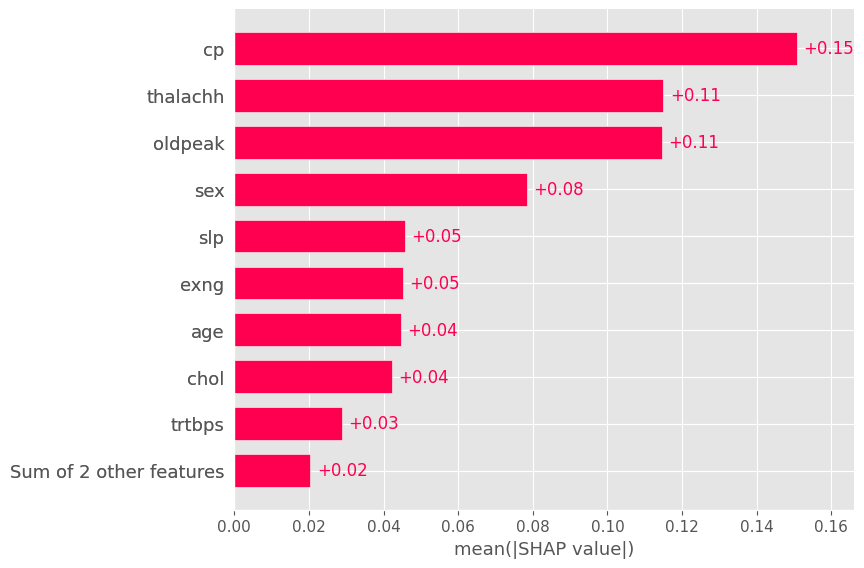

In [53]:
shap.plots.bar(shap_values)